In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from GG4 import Brain
from joblib import Parallel, delayed
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("../shared").resolve()))
sys.path.insert(0, str(Path("../spectral_control").resolve()))
from constants import (
    CAPTIONS_PATH,
    CONTROLLER_COLOURS,
    ERA_EM_4_PATH,
    FIGURES_PATH,
    N_BURNIN,
    N_FFT,
)
from pgf_utils import apply_figure_style, configure_pgf, configure_screen, figure_inches, save_pgf
from system_estimate import SystemEstimate

from spectral_control import (
    LQGController,
    LQIController,
    MPCController,
    SpectralTarget,
    SystemModel,
    random_search,
)
from spectral_control_metrics import (
    NOTEBOOK_GITHUB_URL,
    _eval_seed,
    make_metrics_figure,
)

In [2]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
ESTIMATOR_PATH = ERA_EM_4_PATH

T_SIM    = 400   # closed-loop steps per seed
T_OPT    = 200   # steps used during hyperparameter search
N_TRIALS = 8     # random-search trials per controller
OPT_SEED = 1     # RNG seed for hyperparameter search (matches spectral_control)
N_SEEDS  = 20    # brain seeds for evaluation

OFFSET = 4
TARGET_COMPONENTS = [
    (0.01, 1.5, 0.0),  # (freq, amplitude, phase)
    (0.03, 1.5, 0.0),
]
LAMBDA_VAR  = 1.0
MPC_HORIZON = 30

COLOURS = CONTROLLER_COLOURS

PARAM_SPACES = {
    "LQG": {"q_track": (1.0, 200.0), "r_effort": (10.0, 2000.0)},
    "LQI": {"q_track": (1.0, 200.0), "r_effort": (10.0, 2000.0), "q_int": (0.001, 0.1)},
    "MPC": {"q_track": (1.0, 200.0), "r_u": (1.0, 100.0), "r_du": (1.0, 100.0)},
}

In [3]:
# ── 3. Derived variables ──────────────────────────────────────────────────────
est = SystemEstimate.load(ESTIMATOR_PATH)
model = SystemModel.from_estimate(est, y_mean=np.zeros(16))
target = SpectralTarget(TARGET_COMPONENTS, offset=OFFSET)

MAKE_CTRL = {
    "LQG": lambda p: LQGController(model, lambda_var=LAMBDA_VAR, **p),
    "LQI": lambda p: LQIController(model, lambda_var=LAMBDA_VAR, **p),
    "MPC": lambda p: MPCController(model, horizon=MPC_HORIZON, lambda_var=LAMBDA_VAR, **p),
}

print(f"Estimator: {est.label}  (n_x = {model.n_x})")
print(f"N_SEEDS: {N_SEEDS}, T_SIM: {T_SIM}")

Estimator: ERA+EM $n_x=4$  (n_x = 4)
N_SEEDS: 20, T_SIM: 400


In [4]:
# ── 4. Hyperparameter search ──────────────────────────────────────────────────
# Same seed as spectral_control notebook — identical best_params.
best_params = {}

def brain_factory_opt():
    from constants import RANDOM_SEED
    return Brain(random_seed=RANDOM_SEED)

with tqdm(total=N_TRIALS * len(PARAM_SPACES), desc="Searching", unit="run") as pbar:
    for name, space in PARAM_SPACES.items():
        params, err = random_search(
            brain_factory=brain_factory_opt,
            model=model,
            target=target,
            make_ctrl=MAKE_CTRL[name],
            param_space=space,
            n_trials=N_TRIALS,
            T_opt=T_OPT,
            warmup=T_OPT // 4,
            seed=OPT_SEED,
            n_burnin=N_BURNIN,
        )
        best_params[name] = params
        pbar.update(N_TRIALS)
        print(f"{name}: best RMS={err:.4f}  params={params}")

Searching:   0%|          | 0/24 [00:00<?, ?run/s]

LQG: best RMS=1.1332  params={'q_track': 18.39211021406778, 'r_effort': 11.572157775836274}
LQI: best RMS=1.0691  params={'q_track': 2.938709193146158, 'r_effort': 40.141247440775665, 'q_int': 0.031675927863265146}
MPC: best RMS=1.7308  params={'q_track': 11.053816395879764, 'r_u': 1.8538875781431292, 'r_du': 6.400677900893796}


In [5]:
# ── 5. Evaluation over seeds ──────────────────────────────────────────────────
# Each job is one brain seed evaluated against all three controllers.
# Expected: spectral_rms_error ~0.5–1.0 for LQG/LQI, ~0.9–1.5 for MPC.
# off_target_power should remain <0.05 for all controllers.
jobs = [
    delayed(_eval_seed)(
        seed=s,
        estimator_path=str(ESTIMATOR_PATH),
        best_params=best_params,
        target_components=TARGET_COMPONENTS,
        offset=OFFSET,
        lambda_var=LAMBDA_VAR,
        mpc_horizon=MPC_HORIZON,
        t_sim=T_SIM,
        n_burnin=N_BURNIN,
        n_fft=N_FFT,
    )
    for s in range(N_SEEDS)
]

all_metrics = []
with tqdm(total=N_SEEDS, desc="Evaluating", unit="seed") as pbar:
    for df in Parallel(n_jobs=-1, return_as="generator_unordered")(jobs):
        all_metrics.append(df)
        pbar.update(1)

ctrl_order = list(PARAM_SPACES.keys())
metrics_stack = pd.concat(all_metrics)
metrics_mean = metrics_stack.groupby("controller").mean().loc[ctrl_order]
metrics_sem  = metrics_stack.groupby("controller").sem().loc[ctrl_order]

print(f"\nSpectral metrics (mean \u00b1 SEM, N={N_SEEDS} seeds):")
for col in metrics_mean.columns:
    print(f"\n{col}:")
    for c in ctrl_order:
        print(f"  {c}: {metrics_mean.loc[c, col]:.4f} \u00b1 {metrics_sem.loc[c, col]:.4f}")

Evaluating:   0%|          | 0/20 [00:00<?, ?seed/s]


Spectral metrics (mean ± SEM, N=20 seeds):

spectral_rms_error:
  LQG: 0.6245 ± 0.0086
  LQI: 0.5932 ± 0.0089
  MPC: 1.0015 ± 0.0038

spectral_max_error:
  LQG: 0.7400 ± 0.0109
  LQI: 0.7754 ± 0.0134
  MPC: 1.2635 ± 0.0084

off_target_power:
  LQG: 0.0325 ± 0.0003
  LQI: 0.0329 ± 0.0003
  MPC: 0.0312 ± 0.0003

control_effort:
  LQG: 0.3881 ± 0.0020
  LQI: 0.3232 ± 0.0013
  MPC: 0.3236 ± 0.0047


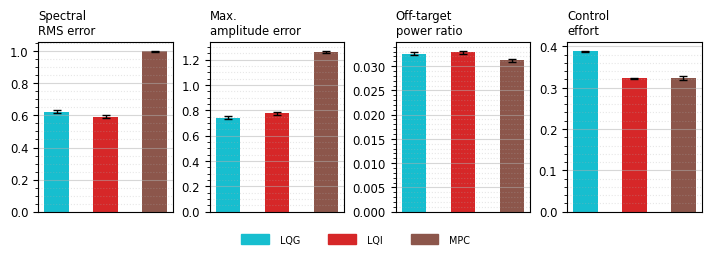

In [6]:
# ── 6. Display ────────────────────────────────────────────────────────────────
configure_screen()
fig = make_metrics_figure(metrics_mean, metrics_sem, controller_colours=COLOURS, figsize=(7, 2.5))
apply_figure_style(fig)
plt.show()

In [7]:
# ── 7. PGF export ─────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 0.5
FIG_HEIGHT_FRAC = 0.18

configure_pgf()
fig = make_metrics_figure(
    metrics_mean,
    metrics_sem,
    controller_colours=COLOURS,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "spectral_control_metrics.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/spectral_control_metrics.pgf


In [8]:
# ── 8. Caption ────────────────────────────────────────────────────────────────
from pgf_utils import save_caption

freq_str = ", ".join(f"{c[0]:.2f}" for c in TARGET_COMPONENTS)
amp_str  = ", ".join(f"{c[1]:.2f}" for c in TARGET_COMPONENTS)

caption = (
    f"Spectral tracking metrics for LQG, LQI, and MPC controllers using the "
    f"{est.label} model ($n_x = {model.n_x}$). "
    f"Each controller was tuned by random search ({N_TRIALS} trials, seed {OPT_SEED}) "
    f"and evaluated over $N = {N_SEEDS}$ independent brain seeds. "
    f"The target was a sum of sinusoids at $f \\in \\{{{freq_str}\\}}$ cycles per sample "
    f"with amplitudes $A \\in \\{{{amp_str}\\}}$, centred on a physical mean of {OFFSET}. "
    "Bars show the mean; error bars show the standard error of the mean. "
    "Left: spectral RMS error (RMS amplitude deviation at target frequencies). "
    "Centre: maximum amplitude error (worst-case per-component deviation). "
    "Right: off-target power ratio (mean spectral amplitude at non-target "
    "frequencies relative to mean target amplitude)."
)

save_caption(CAPTIONS_PATH / "spectral_control_metrics.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/spectral_control_metrics.tex
Spectral tracking metrics for LQG, LQI, and MPC controllers using the ERA+EM $n_x=4$ model ($n_x = 4$). Each controller was tuned by random search (8 trials, seed 1) and evaluated over $N = 20$ independent brain seeds. The target was a sum of sinusoids at $f \in \{0.01, 0.03\}$ cycles per sample with amplitudes $A \in \{1.50, 1.50\}$, centred on a physical mean of 4. Bars show the mean; error bars show the standard error of the mean. Left: spectral RMS error (RMS amplitude deviation at target frequencies). Centre: maximum amplitude error (worst-case per-component deviation). Right: off-target power ratio (mean spectral amplitude at non-target frequencies relative to mean target amplitude).
